<a href="https://colab.research.google.com/github/Alenushka2013/Python_Data_Science/blob/master/230210_3_1_GNN_RandomWalk_Word2Vec.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Graph Neural Networks (GNN)

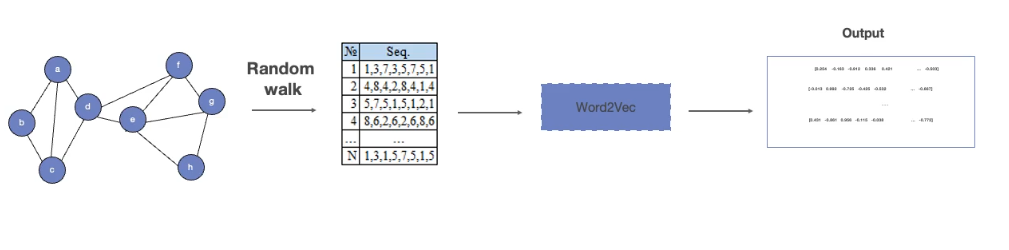

In [2]:
# !pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 60.0 MB/s eta 0:00:00


In [4]:
from gensim.models import Word2Vec
import random
import matplotlib.pyplot as plt

In [6]:
# !pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 51.6 MB/s eta 0:00:00


In [7]:
from torch_geometric.utils import to_networkx
import networkx as nx

In [9]:
# Завантаження датасету CoraFull
from torch_geometric.datasets import CoraFull
dataset = CoraFull(root = "data/CoraFull")
data = dataset[0]

print(f"Граф має {data.num_nodes} вузлів і {data.num_edges} ребер.")
print(f"Число класів: {dataset.num_classes}")

Граф має 19793 вузлів і 126842 ребер.
Число класів: 70


In [12]:
# Перетворення графу в формат networkx
G = to_networkx(data, to_undirected=True)

# # Візуалізація структури графу
# nx.draw(G, node_size = 10, node_color = 'blue')
# plt.show()

In [13]:
# Реалізація випадкового блукання
def random_walk(graph, start_node, walk_length):
  """
  Виконує випадкові блукання по графу, починаючи з вказаного вузла.
  Args:
    graph (networkx.Graph) :  Граф для блукань
    start_node (int) : Вузел, з якого починається блукання
    walk_lenght (int) : Довжина блукання

  Returns:
    list: Список вузлів, відвіданих під час блукання
  """
  walk = [start_node]
  for _ in range(walk_length - 1):
    neighbors = list(graph.neighbors(walk[-1]))
    if not neighbors: # Якщо у вузла немає сусідів зупинити блукання
      break
    next_node = random.choice(neighbors)
    walk.append(next_node)
  return walk

# Генерація випадкових блукань
def generate_walks(graph, num_walks, walk_length):
  """
  Генерує випадкові блукання для кожного вузла графу.
  Args:
    graph (networkx.Graph) :  Граф для блукань
    num_walks (int) : Кількість блукань для кожного вузла
    walk_lenght (int) : Довжина блукання

  Returns:
    list: Список всіх блукань (кожне блукання - це список вузлів).
  """
  walks = []
  for _ in range(num_walks):
    for node in graph.nodes():
      walks.append(random_walk(graph, node, walk_length))
  return walks



In [14]:
# Параметри для випадкових блукань
num_walks = 10
walk_length = 5

# Генерація випадкових блукань
walks = generate_walks(G, num_walks, walk_length)

In [15]:
len(walks)

197930

In [16]:
len(walks[0])

5

In [17]:
print(f"Приклад випадкових блукань: {walks[:2]}")

Приклад випадкових блукань: [[0, 1227, 1244, 13059, 1244], [1, 101, 16, 101, 4]]


# Навчання Word2Vec для вузлів

In [18]:
# Перетворення вузлів в рядки для роботи з Word2Vec
walks = [[str(node) for node in walk] for walk in walks]

# Навчання Word2Vec
model = Word2Vec(sentences = walks, vector_size = 64, window = 5, min_count = 1, sg = 1, workers = 4, epochs = 10)

# Отримання ембеддингів вузлів
node_embeddings = {int(node): model.wv[node] for node in model.wv.index_to_key}

In [22]:
print(f"Приклад ембедингів вузлів: {list(node_embeddings.items())[:2]}")

Приклад ембедингів вузлів: [(14810, array([ 0.5957523 ,  0.5319329 ,  0.9926108 ,  0.72818696, -1.4103825 ,
       -0.96112365,  1.3549056 ,  1.0016291 , -0.5634734 , -0.14062932,
       -0.07845615,  0.10310543, -0.43547928,  0.7748076 , -0.65859187,
       -0.14218725,  0.39723253, -0.09113005, -1.3685367 , -0.3837688 ,
        1.5409037 ,  0.5662976 ,  1.2304622 , -0.18857579, -0.03036284,
        0.68862516, -1.4296188 ,  1.3032358 , -1.1426243 , -0.4327491 ,
       -0.53573805, -0.3728864 , -0.3745971 , -1.3420287 , -0.20886031,
        0.04480468, -0.60580456, -1.5220714 , -0.87664324, -0.70473516,
       -1.1244032 , -0.13313052, -0.5639769 , -0.82804245,  0.55250794,
       -0.5548767 , -1.1198014 ,  0.753449  ,  0.41353786,  0.8265539 ,
        0.5871125 ,  0.649702  ,  0.0361176 ,  0.3149158 ,  0.763904  ,
       -0.48570392,  0.16055141, -0.43917248, -0.3749738 ,  0.36681244,
       -0.32255197, -0.02895323,  0.613704  , -0.5628018 ], dtype=float32)), (9554, array([ 0.462958

# Візуалізація ембедингів

In [23]:
from sklearn.manifold import TSNE
import numpy as np

In [24]:
# Перетворення ембедингів в масив
embeddings_matrix = np.array(list(node_embeddings.values()))

# TSNE для зниження розмірності до 2d
embeddings_2d = TSNE(n_components = 2, random_state = 42).fit_transform(embeddings_matrix)

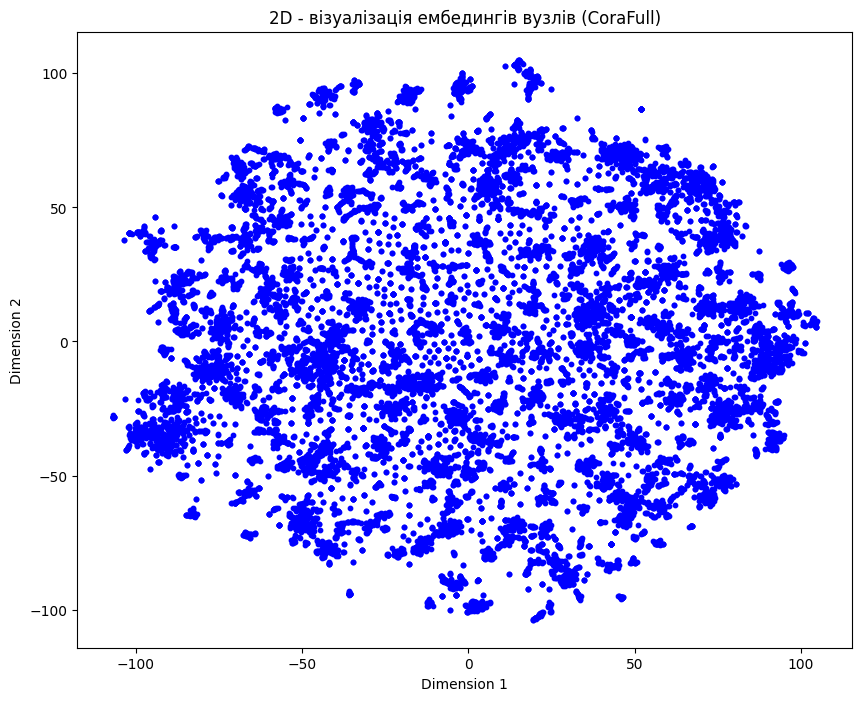

In [25]:
# Побудова візуалізації
plt.figure(figsize = (10, 8))
for i, (x, y) in enumerate(embeddings_2d):
  plt.scatter(x, y, s = 10, color = "blue")
plt.title("2D - візуалізація ембедингів вузлів (CoraFull)")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.show()

#  Класифікація вузлів

In [26]:
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier


In [27]:
def classify_nodes(embeddings, labels, test_size = 0.3):
  """
  Навчає класифікатор на основі візлових ембедингів і передбачає класи вузлів.

  Args:
    embeddings (dict): Словник ембедингів вузлів
    labels (numpy.ndarray): Масив міток вузлів
    test_size (float): Доля тестової вибірки (від 0 до 1).

  Returns:
    float: Точність класифікації

  """
  X = np.array([embeddings[node] for node in range(len(labels))]) # Ембединги вузлів
  y = labels

  # Розподіл на тренувальні і тестові дані
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = test_size, random_state = 42, stratify = y)

  # Навчання класифікатора
  clf = RandomForestClassifier(n_estimators = 100, random_state = 42)
  clf.fit(X_train, y_train)

  #
  y_pred = clf.predict(X_test)
  accuracy = accuracy_score(y_test, y_pred)

  return accuracy

In [28]:
# Класифікація вузлів
labels = data.y.numpy()
accuracy = classify_nodes(node_embeddings, labels)
print(f"Точність класифікації вузлів: {accuracy:.2f}")

Точність класифікації вузлів: 0.67
